# Market-Basket Analysis on IMDB Actors

This notebook implements a market-basket analysis system using the IMDB Movies Dataset from Kaggle.

Each movie is treated as a basket, and the actors listed in the columns `Star1`, `Star2`, `Star3`, and `Star4` are treated as items.

The goal is to discover frequent actor combinations and association rules using frequent itemset mining.

In [1]:
!pip install kaggle

In [2]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from itertools import combinations
from collections import defaultdict

In [3]:
os.environ["KAGGLE_USERNAME"] = "xxxxxx"
os.environ["KAGGLE_KEY"] = "xxxxxx"

## 1. Download the dataset

In [4]:
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
100% 175k/175k [00:00<00:00, 37.3MB/s]



In [5]:
zip_file = "imdb-dataset-of-top-1000-movies-and-tv-shows.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("data")

os.listdir("data")

['imdb_top_1000.csv']

In [6]:
df = pd.read_csv("data/imdb_top_1000.csv")
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## 2. Create the baskets

In [7]:
# Columns containing the actors for each movie
actor_columns = ["Star1", "Star2", "Star3", "Star4"]

# Convert each movie row into a basket of actors
transactions = (
    df[actor_columns]
    .dropna(how="all")
    .apply(
        lambda row: sorted(set(actor.strip() for actor in row.dropna().astype(str))),
        axis=1
    )
    .tolist()
)

transactions[:5]

[['Bob Gunton', 'Morgan Freeman', 'Tim Robbins', 'William Sadler'],
 ['Al Pacino', 'Diane Keaton', 'James Caan', 'Marlon Brando'],
 ['Aaron Eckhart', 'Christian Bale', 'Heath Ledger', 'Michael Caine'],
 ['Al Pacino', 'Diane Keaton', 'Robert De Niro', 'Robert Duvall'],
 ['Henry Fonda', 'John Fiedler', 'Lee J. Cobb', 'Martin Balsam']]

In [8]:
# Basic dataset information
print("Number of movies:", len(df))
print("Number of baskets:", len(transactions))

# Count unique actors appearing in transactions
unique_actors = set()

for basket in transactions:
    for actor in basket:
        unique_actors.add(actor)

print("Number of unique actors:", len(unique_actors))
print("Average basket size:", sum(len(basket) for basket in transactions) / len(transactions))

Number of movies: 1000
Number of baskets: 1000
Number of unique actors: 2709
Average basket size: 3.996


## 3. Implement A-Priori

In [9]:
def get_support_count(transactions, candidates):
    """
    Count how many baskets contain each candidate itemset

    It does not compare every candidate with every basket. It generates
    only the combinations that actually appear inside each basket.
    """

    # Dictionary to store the support count of each candidate itemset
    counts = defaultdict(int)

    candidate_set = set(candidates)

    # If no candidates, return empty counts
    if not candidate_set:
        return counts

    # Compute size of candidate set
    k = len(next(iter(candidate_set)))

    # Loop through each movie basket
    for basket in transactions:

        # Sort actors so combinations always have the same order
        basket_items = sorted(basket)

        # Generate only combinations of size k that appear in this basket
        for comb in combinations(basket_items, k):

            # Count the combination only if it is a candidate itemset
            if comb in candidate_set:
                counts[comb] += 1

    return counts

In [10]:
def apriori(transactions, min_support):
    """
    Find frequent itemsets using the A-Priori algorithm.

    transactions: list of baskets
    min_support: minimum number of baskets an itemset must appear in

    Returns:
    frequent_itemsets: dictionary where
        key = itemset
        value = support count
    """

    # Dictionary to store all frequent itemsets
    frequent_itemsets = {}

    # 1. Count single items

    # Dictionary to count how many times each actor appears
    item_counts = defaultdict(int)

    # Loop through every movie basket, then every actor in the basket
    for basket in transactions:

        for item in basket:

            # Store actors as tuples, so the format is consistent with larger itemsets
            item_counts[(item,)] += 1

    # Keep only actors whose support is at least min_support
    current_frequent_itemsets = {
        itemset: count
        for itemset, count in item_counts.items()
        if count >= min_support
    }

    # Add frequent single actors to dictionary
    frequent_itemsets.update(current_frequent_itemsets)

    k = 2

    # 2. Find frequent pairs, triples, ...

    # Continue only if frequent itemsets of the previous size exist
    while current_frequent_itemsets:

        # Frequent itemsets found in the previous step
        previous_frequent_itemsets = list(current_frequent_itemsets.keys())

        # Candidate itemsets of size k
        candidate_set = set()

        # Generate new candidate itemsets by combining previous frequent itemsets
        for itemset1 in previous_frequent_itemsets:
            for itemset2 in previous_frequent_itemsets:

                # Join two itemsets and sort them to avoid duplicates
                candidate = tuple(sorted(set(itemset1) | set(itemset2)))

                # Keep only candidates of the current size k
                if len(candidate) == k:

                    # subsets of size k-1 must be frequent
                    subsets = combinations(candidate, k - 1)

                    # If every subset is frequent, candidate is valid
                    if all(tuple(sorted(subset)) in current_frequent_itemsets for subset in subsets):
                        candidate_set.add(candidate)

        # Count the support of each valid candidate
        candidate_counts = get_support_count(transactions, candidate_set)

        # Keep candidates that reach the minimum support
        current_frequent_itemsets = {
            itemset: count
            for itemset, count in candidate_counts.items()
            if count >= min_support
        }

        # Add new frequent itemsets to the final result
        frequent_itemsets.update(current_frequent_itemsets)

        # Move to larger itemsets
        k += 1

    # Return all frequent itemsets found
    return frequent_itemsets

In [11]:
# Test different relative support thresholds
for support_fraction in [0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.01]:
    support_count = ceil(support_fraction * len(transactions))
    result = apriori(transactions, support_count)

    print(
        "min_support_fraction =", support_fraction,
        "| min_support_count =", support_count,
        "| frequent itemsets found =", len(result)
    )

min_support_fraction = 0.002 | min_support_count = 2 | frequent itemsets found = 791
min_support_fraction = 0.003 | min_support_count = 3 | frequent itemsets found = 299
min_support_fraction = 0.004 | min_support_count = 4 | frequent itemsets found = 151
min_support_fraction = 0.005 | min_support_count = 5 | frequent itemsets found = 83
min_support_fraction = 0.006 | min_support_count = 6 | frequent itemsets found = 60
min_support_fraction = 0.007 | min_support_count = 7 | frequent itemsets found = 30
min_support_fraction = 0.01 | min_support_count = 10 | frequent itemsets found = 9


In [12]:
# Minimum support as a fraction of the dataset
min_support_fraction = 0.005

# Convert the support threshold into an absolute support count
min_support = ceil(min_support_fraction * len(transactions))

print("Minimum support count:", min_support)

Minimum support count: 5


In [13]:
# Count the total number of baskets
num_baskets = len(transactions)

print(num_baskets)

1000


In [14]:
# Run the A-Priori algorithm on the movie baskets
frequent_itemsets = apriori(transactions, min_support)

# Show how many frequent itemsets were found
len(frequent_itemsets)

83

## 4. Show frequent itemsets

In [15]:
# DataFrame where each row represent one frequent itemset found by A-Priori
frequent_df = pd.DataFrame([
    {
        "itemset": itemset,

        "size": len(itemset),

        # Absolute support: number of movies where this itemset appears
        "support_count": support,

        # Relative support: fraction of all movies where this itemset appears
        "support": support / num_baskets
    }

    # Loop through all frequent itemsets
    for itemset, support in frequent_itemsets.items()
])

# Sort the results by itemset size and by support count
frequent_df = frequent_df.sort_values(
    by=["size", "support_count"],
    ascending=[True, False]
)

frequent_df.head(10)

,itemset,size,support_count,support
5,"(Robert De Niro,)",1,17,0.017
13,"(Tom Hanks,)",1,14,0.014
1,"(Al Pacino,)",1,13,0.013
11,"(Brad Pitt,)",1,12,0.012
14,"(Clint Eastwood,)",1,12,0.012
3,"(Christian Bale,)",1,11,0.011
10,"(Leonardo DiCaprio,)",1,11,0.011
19,"(Matt Damon,)",1,11,0.011
25,"(James Stewart,)",1,10,0.010
4,"(Michael Caine,)",1,9,0.009


In [16]:
# Display frequent single actors
frequent_df[frequent_df["size"] == 1].head(10)

,itemset,size,support_count,support
5,"(Robert De Niro,)",1,17,0.017
13,"(Tom Hanks,)",1,14,0.014
1,"(Al Pacino,)",1,13,0.013
11,"(Brad Pitt,)",1,12,0.012
14,"(Clint Eastwood,)",1,12,0.012
3,"(Christian Bale,)",1,11,0.011
10,"(Leonardo DiCaprio,)",1,11,0.011
19,"(Matt Damon,)",1,11,0.011
25,"(James Stewart,)",1,10,0.010
4,"(Michael Caine,)",1,9,0.009


In [17]:
# Display frequent pairs of actors
frequent_df[frequent_df["size"] == 2].head(10)

,itemset,size,support_count,support
80,"(Daniel Radcliffe, Rupert Grint)",2,6,0.006
79,"(Daniel Radcliffe, Emma Watson)",2,5,0.005
81,"(Emma Watson, Rupert Grint)",2,5,0.005


In [18]:
# Display frequent triples of actors
frequent_df[frequent_df["size"] == 3].head(10)

,itemset,size,support_count,support
82,"(Daniel Radcliffe, Emma Watson, Rupert Grint)",3,5,0.005


## 5. Association rules

In [19]:
def generate_association_rules(frequent_itemsets, num_baskets, min_confidence=0.5):
    """
    Generate association rules from the frequent itemsets found by A-Priori

    Dictionary frequent_itemsets:
        key = frequent itemset
        value = support count of that itemset

    num_baskets:
        Total number of movie baskets

    min_confidence:
        Minimum confidence required to keep an association rule

    Returns:
        A pandas DataFrame containing the association rules
    """

    # List to store association rules that satisfy min_confidence
    rules = []

    # Loop through every frequent itemset found by A-Priori
    for itemset, itemset_support_count in frequent_itemsets.items():

        # Itemsets containing at least 2 actors
        if len(itemset) < 2:
            continue

        itemset_set = set(itemset)

        # Generate all possible sizes for the left-hand side of the rule
        for r in range(1, len(itemset)):

            # Generate all possible antecedents of size r
            for antecedent in combinations(itemset, r):

                antecedent = tuple(sorted(antecedent))

                # It contains the actors in the itemset that are not in the antecedent
                consequent = tuple(sorted(itemset_set - set(antecedent)))

                # Get the support of the antecedent to calculate confidence
                if antecedent in frequent_itemsets:

                    # Support count of the full itemset:
                    full_itemset_support_count = itemset_support_count

                    # Support count of the antecedent
                    antecedent_support_count = frequent_itemsets[antecedent]

                    # confidence(A -> B) = support(A ∪ B) / support(A)
                    confidence = full_itemset_support_count / antecedent_support_count

                    # Support count of the consequent
                    consequent_support_count = frequent_itemsets[consequent]

                    # Support count of the consequent
                    consequent_support = consequent_support_count / num_baskets

                    # interest(A -> B) = confidence(A -> B) - support(B)
                    interest = confidence - consequent_support

                    # Keep only rules whose confidence is high enough
                    if confidence >= min_confidence:

                        # Store the rule and its statistics
                        rules.append({
                            "antecedent": antecedent,
                            "consequent": consequent,
                            "support_count": full_itemset_support_count,
                            "support": full_itemset_support_count / num_baskets,
                            "confidence": confidence,
                            "interest": interest
                        })

    # Convert the list of rules into a pandas DataFrame
    return pd.DataFrame(rules)

In [20]:
# Generate association rules from the frequent itemsets
rules_df = generate_association_rules(
    frequent_itemsets,
    num_baskets,
    min_confidence=0.5
)

In [21]:
# Sort the rules by confidence and support_count
rules_df = rules_df.sort_values(
    by=["confidence", "support_count"],
    ascending=[False, False]
)

rules_df.head(10)

,antecedent,consequent,support_count,support,confidence,interest
2,"(Daniel Radcliffe,)","(Rupert Grint,)",6,0.006,1.000000,0.994000
3,"(Rupert Grint,)","(Daniel Radcliffe,)",6,0.006,1.000000,0.994000
9,"(Daniel Radcliffe, Emma Watson)","(Rupert Grint,)",5,0.005,1.000000,0.994000
11,"(Emma Watson, Rupert Grint)","(Daniel Radcliffe,)",5,0.005,1.000000,0.994000
0,"(Daniel Radcliffe,)","(Emma Watson,)",5,0.005,0.833333,0.826333
5,"(Rupert Grint,)","(Emma Watson,)",5,0.005,0.833333,0.826333
6,"(Daniel Radcliffe,)","(Emma Watson, Rupert Grint)",5,0.005,0.833333,0.828333
8,"(Rupert Grint,)","(Daniel Radcliffe, Emma Watson)",5,0.005,0.833333,0.828333
10,"(Daniel Radcliffe, Rupert Grint)","(Emma Watson,)",5,0.005,0.833333,0.826333
1,"(Emma Watson,)","(Daniel Radcliffe,)",5,0.005,0.714286,0.708286


## 6. Make the output more readable

In [32]:
# Convert itemset tuple into a readable string
def itemset_to_string(itemset):
    return ", ".join(itemset)

# Add readable version of each frequent itemset to the dataframe
frequent_df["itemset_str"] = frequent_df["itemset"].apply(itemset_to_string)

frequent_df[["itemset_str", "size", "support_count", "support"]].head(10)

,itemset_str,size,support_count,support
5,Robert De Niro,1,17,0.017
13,Tom Hanks,1,14,0.014
1,Al Pacino,1,13,0.013
11,Brad Pitt,1,12,0.012
14,Clint Eastwood,1,12,0.012
3,Christian Bale,1,11,0.011
10,Leonardo DiCaprio,1,11,0.011
19,Matt Damon,1,11,0.011
25,James Stewart,1,10,0.010
4,Michael Caine,1,9,0.009


In [33]:
# Continue only if at least one association rule was generated
if not rules_df.empty:

    # Convert the antecedent into a readable string
    rules_df["antecedent_str"] = rules_df["antecedent"].apply(itemset_to_string)

    # Convert the consequent into a readable string
    rules_df["consequent_str"] = rules_df["consequent"].apply(itemset_to_string)

    display(rules_df[[
        "antecedent_str",
        "consequent_str",
        "support_count",
        "support",
        "confidence",
        "interest"
    ]].head(10))

else:
    print("No association rules were generated.")

,antecedent_str,consequent_str,support_count,support,confidence,interest
2,Daniel Radcliffe,Rupert Grint,6,0.006,1.000000,0.994000
3,Rupert Grint,Daniel Radcliffe,6,0.006,1.000000,0.994000
9,"Daniel Radcliffe, Emma Watson",Rupert Grint,5,0.005,1.000000,0.994000
11,"Emma Watson, Rupert Grint",Daniel Radcliffe,5,0.005,1.000000,0.994000
0,Daniel Radcliffe,Emma Watson,5,0.005,0.833333,0.826333
5,Rupert Grint,Emma Watson,5,0.005,0.833333,0.826333
6,Daniel Radcliffe,"Emma Watson, Rupert Grint",5,0.005,0.833333,0.828333
8,Rupert Grint,"Daniel Radcliffe, Emma Watson",5,0.005,0.833333,0.828333
10,"Daniel Radcliffe, Rupert Grint",Emma Watson,5,0.005,0.833333,0.826333
1,Emma Watson,Daniel Radcliffe,5,0.005,0.714286,0.708286


## 7. Visualization

In [24]:
# Count how many singleton pairs are found
len(frequent_df[frequent_df["size"] == 1])

79

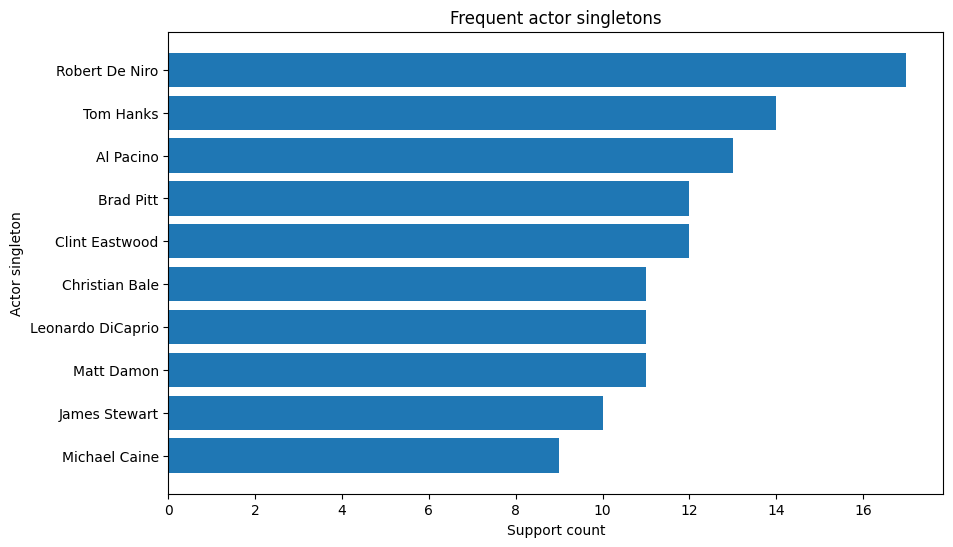

In [25]:
top_itemsets = frequent_df[frequent_df["size"] == 1].head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_itemsets["itemset_str"], top_itemsets["support_count"])
plt.xlabel("Support count")
plt.ylabel("Actor singleton")
plt.title("Frequent actor singletons")
plt.gca().invert_yaxis()
plt.show()

In [26]:
# Count how many frequent pairs are found
len(frequent_df[frequent_df["size"] == 2])

3

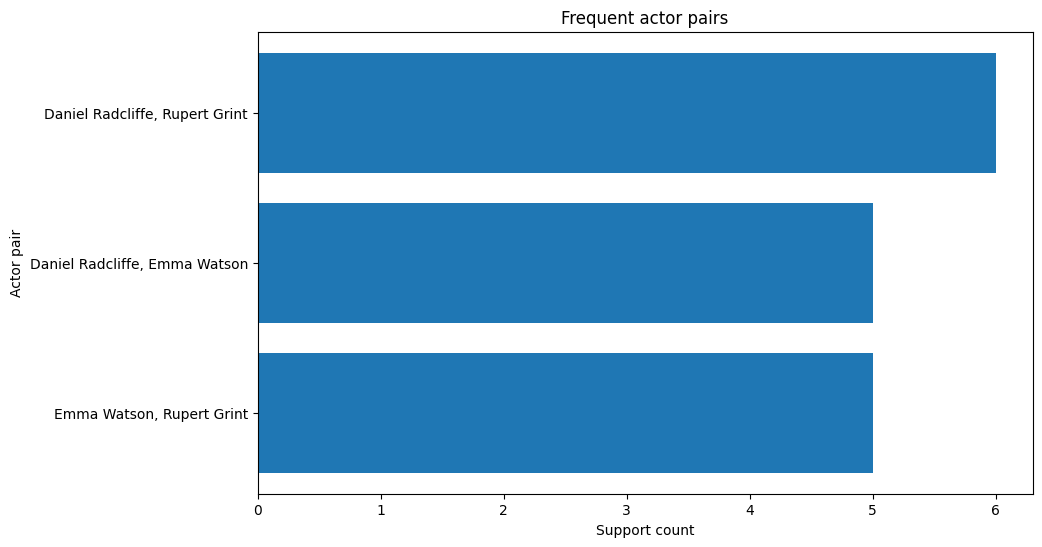

In [27]:
top_itemsets = frequent_df[frequent_df["size"] == 2].head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_itemsets["itemset_str"], top_itemsets["support_count"])
plt.xlabel("Support count")
plt.ylabel("Actor pair")
plt.title("Frequent actor pairs")
plt.gca().invert_yaxis()
plt.show()

In [28]:
# Count how many frequent triples are found
len(frequent_df[frequent_df["size"] == 3])

1

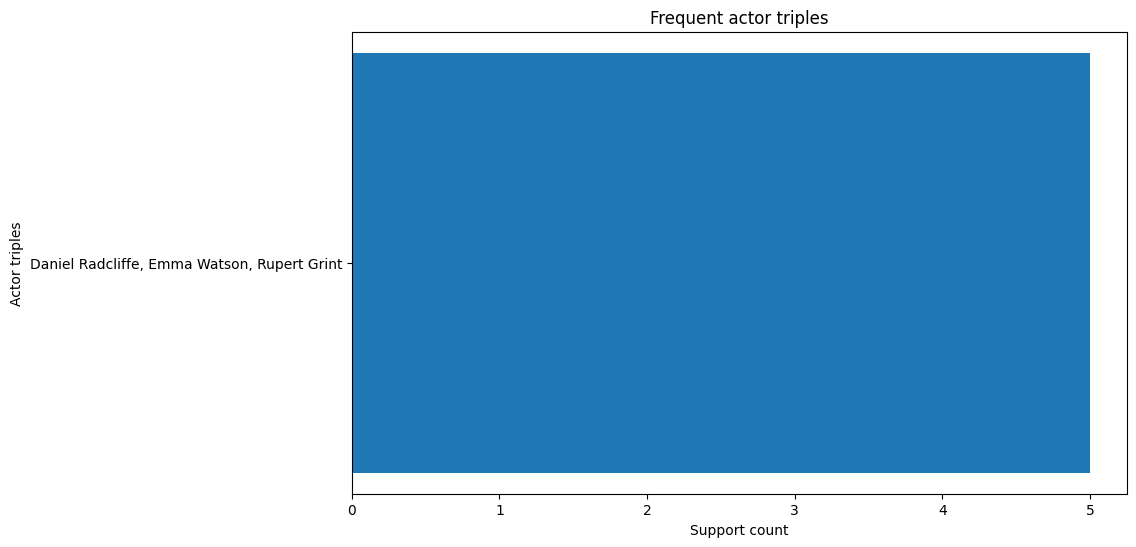

In [29]:
top_itemsets = frequent_df[frequent_df["size"] == 3].head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_itemsets["itemset_str"], top_itemsets["support_count"])
plt.xlabel("Support count")
plt.ylabel("Actor triples")
plt.title("Frequent actor triples")
plt.gca().invert_yaxis()
plt.show()

In [30]:
# Count how many frequent quadruples are found
len(frequent_df[frequent_df["size"] == 4])

0

## 8. Export results to csv

In [31]:
# Save frequent itemsets to CSV
frequent_df.to_csv("frequent_itemsets.csv", index=False)

# Save association rules to CSV
rules_df.to_csv("association_rules.csv", index=False)